# Mixture of Mixture of Gaussians Example

In [45]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib
import scipy
from copy import copy
from sklearn.preprocessing import KernelCenterer

#import code to generate data and do clustNP
from sample_distributions import pair_sample_mixture_of_GMs
from NDIGO import gauss_kernal_mat, proj_simplex

# Set Parameters

In [46]:
np.random.seed(123)

n = 150 # number of total paired samples
nhold = 100
ntest = 100
M = 1   # true number of mixture components for our KDE
Mprime = 1
d = 1   # ambient dimension 

#w_outer = np.random.rand(M,) # true KDE mixture proportions
w_outer = np.ones((M,))
w_outer *= 1/np.sum(w_outer)
w_inner = np.ones((M,1))
#mus = 2*np.random.randn(1, d, M) # true means for each mixture distribution
mus = np.ones((1, d, M))
#mus[0,0,0] = -2
sigmas = np.ones((1,d,d,M))


noise_sd = 0.8

# Generate Data

In [47]:
X, component_ids, pair_ids = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=n)
Xh, cid_h, pid_h = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=nhold)
Xte, cid_te, pid_te = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=ntest)
w_outer

X = np.random.uniform(-2,2,(2*n,1)) #just reuse component ids since all are coming from the same distribution

### Plot Pairs as endpoints of line segments

Text(0.5, 0, 'x')

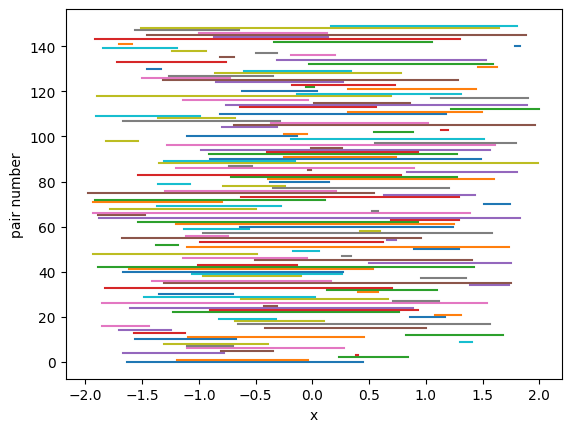

In [48]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Generate func vals

# Nonlinear

In [49]:
#noise_sd_0 = .3
noise_sd_0 = 1.5

Y = np.ndarray((2*n,1))
#Y[(component_ids==0)] = X[component_ids==0]**3 - X[component_ids==0]
Y[(component_ids==0)] = -X[component_ids==0]**4 + X[component_ids==0]**2
Ytrue = copy(Y)
# Y = Y + np.random.normal(0, noise_sd, Y.shape)

noise_sd = np.ndarray((2*n,1))
noise_sd[(component_ids==0)] = noise_sd_0

Y = Y + np.random.normal(0, noise_sd, Y.shape)
# Y[(component_ids==0)] = Y[(component_ids==0)] + np.random.normal(0, noise_sd_0, Y[(component_ids==0)].shape)
# Y[(component_ids==1)] = Y[(component_ids==1)] + np.random.normal(0, noise_sd_1, Y[(component_ids==1)].shape)


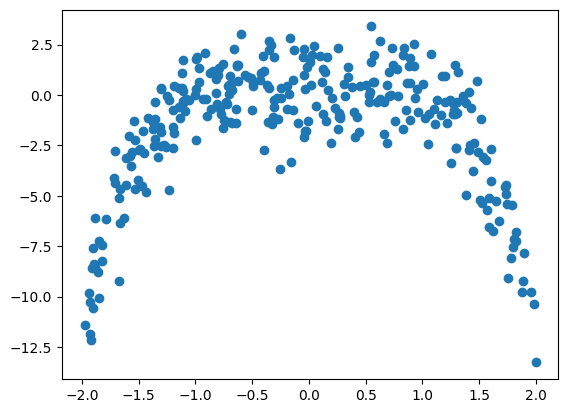

In [50]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

# EM

In [51]:
def lstsq_nesterov(X, Y, alpha0, maxiter=2000):
    Y = Y.flatten()
    ss = 1/np.linalg.norm(X, ord='fro')**2
    alpha = alpha0
    z = alpha0
    gamma = 1
    XtX = X.T@X
    XtY = X.T@Y
    for i in range(maxiter):
        alpha_old = alpha
        alpha = z + ss*(XtY-XtX@z)
        gamma = (np.sqrt(4*gamma**2 + gamma**4) - gamma**2)*0.5
        beta = gamma*(1-1/gamma)
        z = alpha + beta*(alpha - alpha_old)
    return alpha  

In [52]:
# # define model
# model = MyNN()

# for em_iter in range(T):

#     # E-step
#     gamma = compute_responsibilities(...)

#     # M-step (train NN with weights gamma)
#     for step in range(k):
#         preds = model(x)
#         loss = weighted_loss(preds, y, gamma)
#         loss.backward()
#         optimizer.step()


In [53]:
import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------
# Simple feedforward network
# -------------------------
class Net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


# -------------------------
# Weighted loss
# -------------------------
def weighted_mse(pred, target, weights):
    # pred: (n, d)
    # target: (n, d)
    # weights: (n,)
    loss = (pred - target)**2
    loss = loss.mean(dim=1)        # per-sample loss (n,)
    return (weights * loss).sum() / weights.sum()


# -------------------------
# E-step (example placeholder)
# -------------------------

def compute_responsibilities(x, Y, w, models, sigmas):
    x = torch.tensor(x, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)
    
    n2 = x.shape[0]  # total data points = 2 * number of pairs
    M = len(models)
    
    assert n2 % 2 == 0, "n must be even for pairing"

    w_tensor = torch.tensor(w, dtype=torch.float32)
    sigmas_tensor = torch.tensor(sigmas, dtype=torch.float32)

    log_likelihoods = []

    # --- compute per-model log likelihoods only ---
    for im in range(M):
        mu = models[im](x)
        Delta = (Y - mu) ** 2
        
        log_likelihood = (
            -Delta / (2 * sigmas_tensor[im])
            - 0.5 * torch.log(sigmas_tensor[im])
        )

        log_likelihoods.append(log_likelihood.squeeze())

    # shape: (n2, M)
    log_likelihoods = torch.stack(log_likelihoods, dim=1)

    # group the pairs
    log_likelihoods_pairs = log_likelihoods.view(n2 // 2, 2, M)

    # sum likelihoods within each pair
    # shape: (n2/2, M)
    log_likelihood_pairwise = log_likelihoods_pairs.sum(dim=1)

    # add log prior once per pair/component
    # shape of log_prior: (M,)
    log_prior = torch.log(w_tensor)

    # broadcasting gives shape: (n2/2, M)
    log_probs_pairwise = log_likelihood_pairwise + log_prior

    # compute responsibilities at pair level
    gamma_pairwise = torch.softmax(log_probs_pairwise, dim=1)

    # expand back so each pair shares gamma
    gamma = gamma_pairwise.repeat_interleave(2, dim=0)

    return gamma

kern_width = 0.8

K = gauss_kernal_mat(X,X,sigma=kern_width)
# transformer = KernelCentere
#r().fit(K)
# K = transformer.transform(K)
w, A = scipy.sparse.linalg.eigs(K, k=M)
w = np.real(w)
A = np.real(A)
w = w/np.sum(w)
maxiter = 30

R = np.zeros((n,M))


# -------------------------
# Main EM loop
# -------------------------

def EM_train(x, y, M, em_iters=10, inner_steps=10):
    n, d = x.shape
    x = torch.tensor(x, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    # initialize models + optimizers
    models = [Net(d, 48, y.shape[1]) for _ in range(M)]
    opts = [optim.Adam(m.parameters(), lr=1e-3) for m in models]
    sigmas = torch.ones(M, dtype=torch.float32)

    for em_iter in range(em_iters):

        # -----------------
        # E-step
        # -----------------
        gamma = compute_responsibilities(x, y, w, models, sigmas)  # (n, M)
    

        # -----------------
        # M-step
        # -----------------
        for m in range(M):
            model = models[m]
            opt = opts[m]

            weights = gamma[:, m].detach()  # (n,)

            for _ in range(inner_steps):
                opt.zero_grad()

                pred = model(x)
                loss = weighted_mse(pred, y, weights)

                loss.backward()
                opt.step()

        # print(f"EM iter {em_iter} done")
            sigmas[m] = torch.sum(weights * ((y - model(x)).squeeze()**2)) / (torch.sum(weights))
    return models, sigmas

In [54]:
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

models, sigmas = EM_train(X_tensor, Y_tensor, M=1, em_iters=100, inner_steps=100)

C:\Users\jj\AppData\Local\Temp\ipykernel_37788\62125747.py:109: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_37788\62125747.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_37788\62125747.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_37788\62125747.py:39: UserWarning: To copy construc

# Check out the results

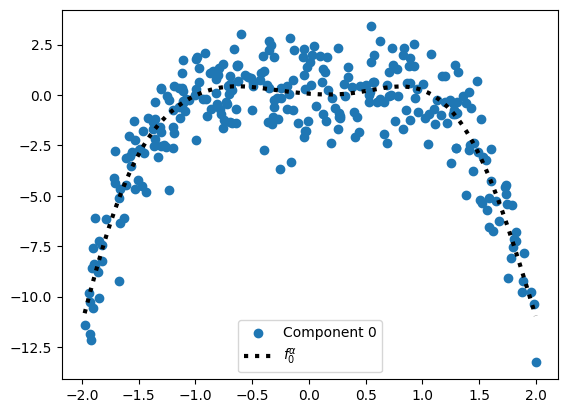

In [55]:
plt.scatter(X[component_ids==0],Y[component_ids==0], label="Component 0")
#plt.scatter(X[component_ids==1],Y[component_ids==1], label="Component 1")

xx = np.reshape(np.linspace(np.min(X),np.max(X),1000), (1000,1))
xx_tensor = torch.tensor(xx, dtype=torch.float32)
# Ktest = gauss_kernal_mat(xx,X,sigma=kern_width)
# Yhat = Ktest@A
Yhat_tens = torch.zeros((xx_tensor.shape[0], M), dtype=torch.float32)  # tensor instead of np.zeros

for m in range(M):
    # forward pass
    Yhat_tens[:, m] = models[m](xx_tensor).squeeze()

Yhat = Yhat_tens.detach().numpy()

# print(Yhat[:,0])
# print(Yhat[:,1])
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
#plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_0^\alpha$")

# Rdouble = np.repeat(R,2,axis=0)
# correct_assignments = max(sum(component_ids==np.argmax(Rdouble,axis=1) ), 
#                           sum((1-component_ids)==np.argmax(Rdouble,axis=1)) 
#                          ) / (2*n)
# print(f"Prop Correct Mixture Assignment = {correct_assignments}")

plt.rcParams.update({'font.size': 10})
plt.legend()

In [56]:
print(sigmas)
print(sigmas**.5)

tensor([1.9409], grad_fn=<CopySlices>)
tensor([1.3932], grad_fn=<PowBackward0>)


IndexError: index 1 is out of bounds for axis 1 with size 1

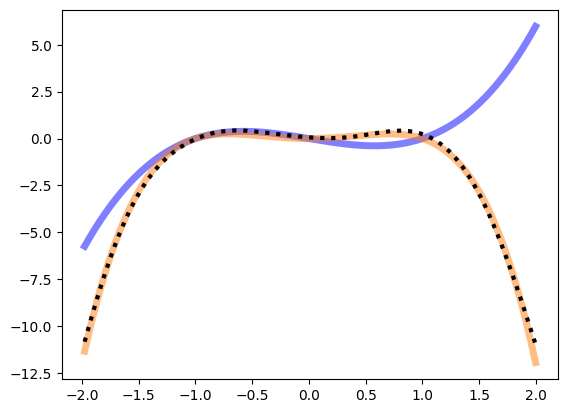

In [57]:
plt.plot(xx, xx**3-xx, 'b', linewidth=5, label="$f_0^*$", alpha=0.5)
plt.plot(xx, -xx**4+xx**2, 'tab:orange', linewidth=5, label="$f_1^*$", alpha=0.5)
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_1^\alpha$")
plt.rcParams.update({'font.size': 10})
plt.legend()


In [ ]:
Rdouble = np.repeat(R,2,axis=0)
plt.scatter(X[np.argmax(Rdouble,axis=1)==0],Yhat[np.argmax(Rdouble,axis=1)==0,0])
plt.scatter(X[np.argmax(Rdouble,axis=1)==1],Yhat[np.argmax(Rdouble,axis=1)==1,1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

IndexError: boolean index did not match indexed array along axis 0; size of axis is 1000 but size of corresponding boolean axis is 300

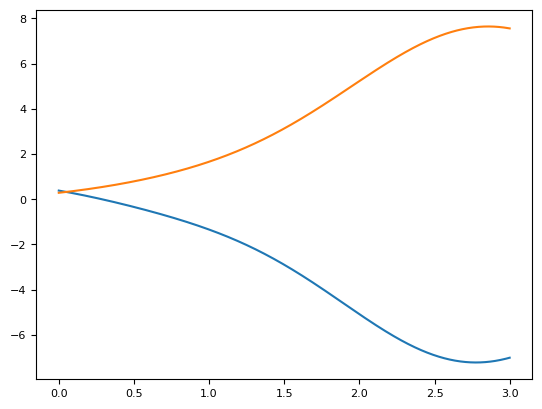

In [ ]:
xx = np.reshape(np.linspace(0,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=0.95)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0])
plt.plot(xx, Yhat[:,1])

In [ ]:
# NTK pseudocode

## Given network f(x;θ) and data X (N inputs), compute NTK matrix K of size N×N
# for i in 1..N:
#     g_i = gradient of f(x_i;θ) w.r.t all parameters θ  # a vector of length P  
#     for j in 1..N:
#         K[i,j] = dot(g_i, g_j)  # compute inner products of gradients  